# Exploratory Analysis

We ran some basic visualisations to better understand our data and determine potential heuristics for ranking merchants.

In [112]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sys, os, glob
import re
import math
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from shapely.geometry import Point
import seaborn as sns
from pyspark.sql import functions as F
from pyspark.sql.types import StructType, StructField, StringType, LongType, IntegerType, DateType, DoubleType

In [113]:
sys.path.insert(0, "../scripts")
from spark_setup import get_spark
spark = get_spark()

# Correlation Matrices
Done on numeric values to inform relevant heuristics/features to use in ranking system.

In [114]:
df = spark.read.parquet('.././data/curated/final_external_enriched')
df.show()

+--------------+--------+------------+-------+------------------+--------------------+-----------+-----------------+--------------------+-----+------+------------------+---------------------+--------------------+--------------------+--------------------+------------+---------+-------------------+------------------+--------------+------------------+-----------------------+------------------+-----------------------------+---------------------------+------------------+-------------------------+----------------------------+-------------------------+----------------------+-------------------+--------------+------------------+----------------+------------------+---------------+------------------+--------------+------------------+--------------+-----------------+---------------+-----------------+
|order_datetime|postcode|merchant_abn|user_id|      dollar_value|            order_id|consumer_id|             name|             address|state|gender| fraud_probability|is_same_day_duplicate|       m

In [115]:
df.select(
    F.count("*").alias("total_rows"),
    F.sum(F.col("Median_age_persons").isNull().cast("int")).alias("missing_census"),
    F.sum(F.col("poa_irsad_score").isNull().cast("int")).alias("missing_seifa"),
    F.sum(F.col("rba_cash_rate_pct").isNull().cast("int")).alias("missing_rba"),
    F.sum(F.col("avg_merchant_fraud_prob").isNull().cast("int")).alias("missing_fraud_label"),
).show()

+----------+--------------+-------------+-----------+-------------------+
|total_rows|missing_census|missing_seifa|missing_rba|missing_fraud_label|
+----------+--------------+-------------+-----------+-------------------+
|  13614675|       2244225|      2329646|          0|           13031129|
+----------+--------------+-------------+-----------+-------------------+



In [116]:
sample_pdf = df.sample(0.05).toPandas()

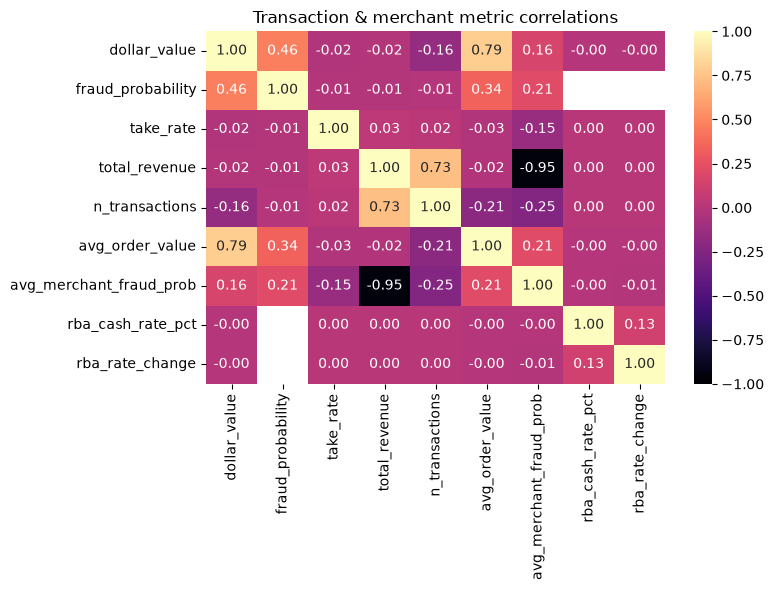

In [117]:
core_cols = [
    "dollar_value", "fraud_probability", "take_rate", "total_revenue",
    "n_transactions", "avg_order_value", "avg_merchant_fraud_prob",
    "rba_cash_rate_pct", "rba_rate_change"
]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(sample_pdf[core_cols].corr(), annot=True, fmt=".2f", cmap="magma",
            vmin=-1, vmax=1, ax=ax)
ax.set_title("Transaction & merchant metric correlations")
plt.tight_layout()
plt.show()

- High negative correlation between avg_merchant_fraud_prob and total_revenue.

- High positive correlation between avg_merchant_fraud and dollar_value.

- 0.73 correlation between total_revenue and n_transaction.

Overall, a merchant's fraud probability correlates mainly with total_revenue. When there is a low average fraud probability, there is a high total revenue. Hence, a merchant with high revenue is less likely to be drawn to commit fraud.

In addition to this, when the purchase has a high dollar value, the average fraud probability is high as well. Thus, expensive items have a correlation with average fraud.

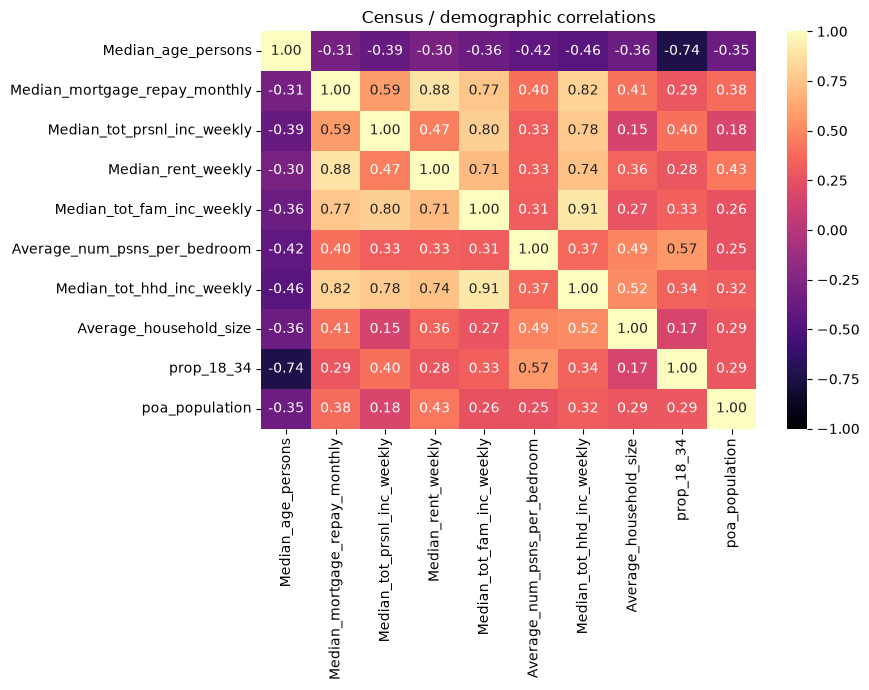

In [118]:
census_cols = [
    "Median_age_persons", "Median_mortgage_repay_monthly", "Median_tot_prsnl_inc_weekly",
    "Median_rent_weekly", "Median_tot_fam_inc_weekly", "Average_num_psns_per_bedroom",
    "Median_tot_hhd_inc_weekly", "Average_household_size", "prop_18_34", "poa_population"
]

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(sample_pdf[census_cols].corr(), annot=True, fmt=".2f", cmap="magma",
            vmin=-1, vmax=1, ax=ax)
ax.set_title("Census / demographic correlations")
plt.tight_layout()
plt.show()

- 0.82 correlation between Median_tot_hhd_inc_weekly and Median_mortage_repay_monthly
- 0.91 correlation between Median_tot_hhd_inc_weekly and Median_tot_fam_inc_weekly.

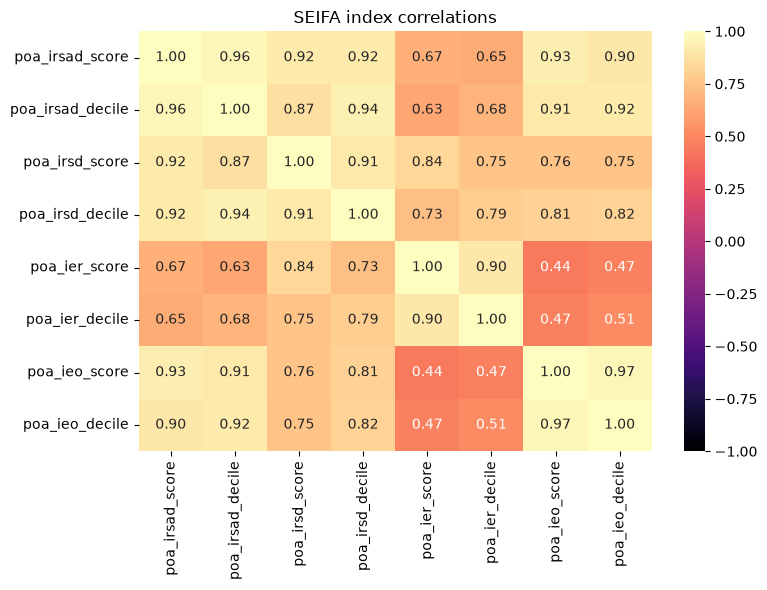

In [119]:
seifa_cols = [
    "poa_irsad_score", "poa_irsad_decile", "poa_irsd_score", "poa_irsd_decile",
    "poa_ier_score", "poa_ier_decile", "poa_ieo_score", "poa_ieo_decile"
]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(sample_pdf[seifa_cols].corr(), annot=True, fmt=".2f", cmap="magma",
            vmin=-1, vmax=1, ax=ax)
ax.set_title("SEIFA index correlations")
plt.tight_layout()
plt.show()

In general, it appears that there is a relatively high correlation between Relative Socio-economic Disadvantage, the Index of Education and Occupation and the Index of Economic Resources. For the case of IER and IEO, a low score in financial aspects doesn't necessarily have a high correlation with educational and occupational disadvantages.

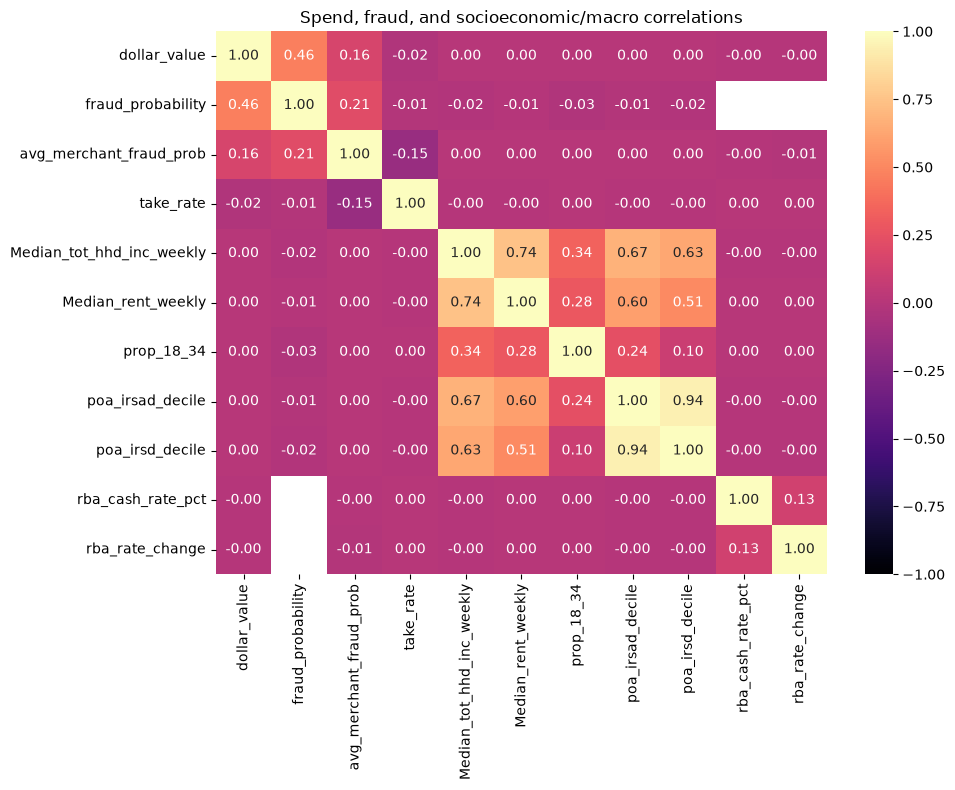

In [120]:
key_cols = [
    "dollar_value", "fraud_probability", "avg_merchant_fraud_prob", "take_rate",
    "Median_tot_hhd_inc_weekly", "Median_rent_weekly", "prop_18_34",
    "poa_irsad_decile", "poa_irsd_decile",
    "rba_cash_rate_pct", "rba_rate_change"
]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(sample_pdf[key_cols].corr(), annot=True, fmt=".2f", cmap="magma",
            vmin=-1, vmax=1, ax=ax)
ax.set_title("Spend, fraud, and socioeconomic/macro correlations")
plt.tight_layout()
plt.show()

# Transaction Level Distributions

The following distributions were done to explore general trends/values in transactions, merchants, customer demographics, socioeconomic factors and interest rate (RBA).


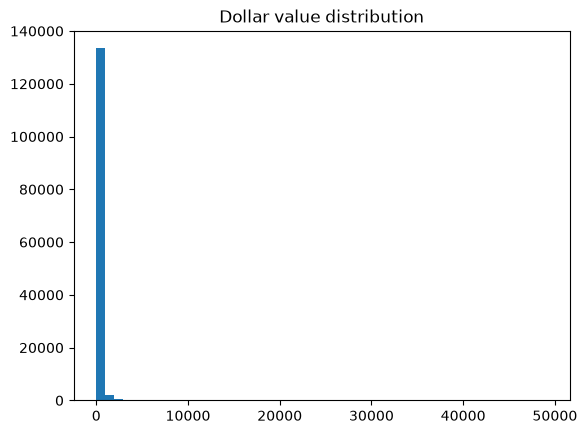

In [121]:
pdf = df.select("dollar_value").sample(0.01).toPandas()  # sample first, full table is large
plt.hist(pdf["dollar_value"], bins=50)
plt.title("Dollar value distribution")
plt.show()

# Merchant Landscape

In [122]:
merchant_summary_category = (df.groupBy("category_group")
    .agg(
        F.sum("dollar_value").alias("total_dollar_value"),
        F.avg("dollar_value").alias("average_dollar_value"),
        F.countDistinct("merchant_abn").alias("n_merchants")
        )
    .orderBy(F.desc("total_dollar_value")))

merchant_summary_category.show(20, truncate=False)

+------------------------+--------------------+--------------------+-----------+
|category_group          |total_dollar_value  |average_dollar_value|n_merchants|
+------------------------+--------------------+--------------------+-----------+
|antiques_art_craft      |2.284566701839877E8 |339.907620112046    |434        |
|technology              |2.1951492439592516E8|177.45462837781537  |372        |
|gardening               |2.1134447807183963E8|171.95199543714426  |333        |
|vehicle                 |1.817372177515415E8 |341.76677690141287  |321        |
|books_media_digital     |1.8171850904199412E8|108.270892182824    |359        |
|gifts_hobby_novelty     |1.7247341483511382E8|91.95865052945094   |324        |
|outdoor_supply          |1.4790184758980724E8|81.40376400457883   |178        |
|health_beauty           |1.4761714537053546E8|135.47306855878855  |315        |
|tv_media_telecom        |1.3509531166400078E8|136.28398054229064  |300        |
|jewelry                 |1.

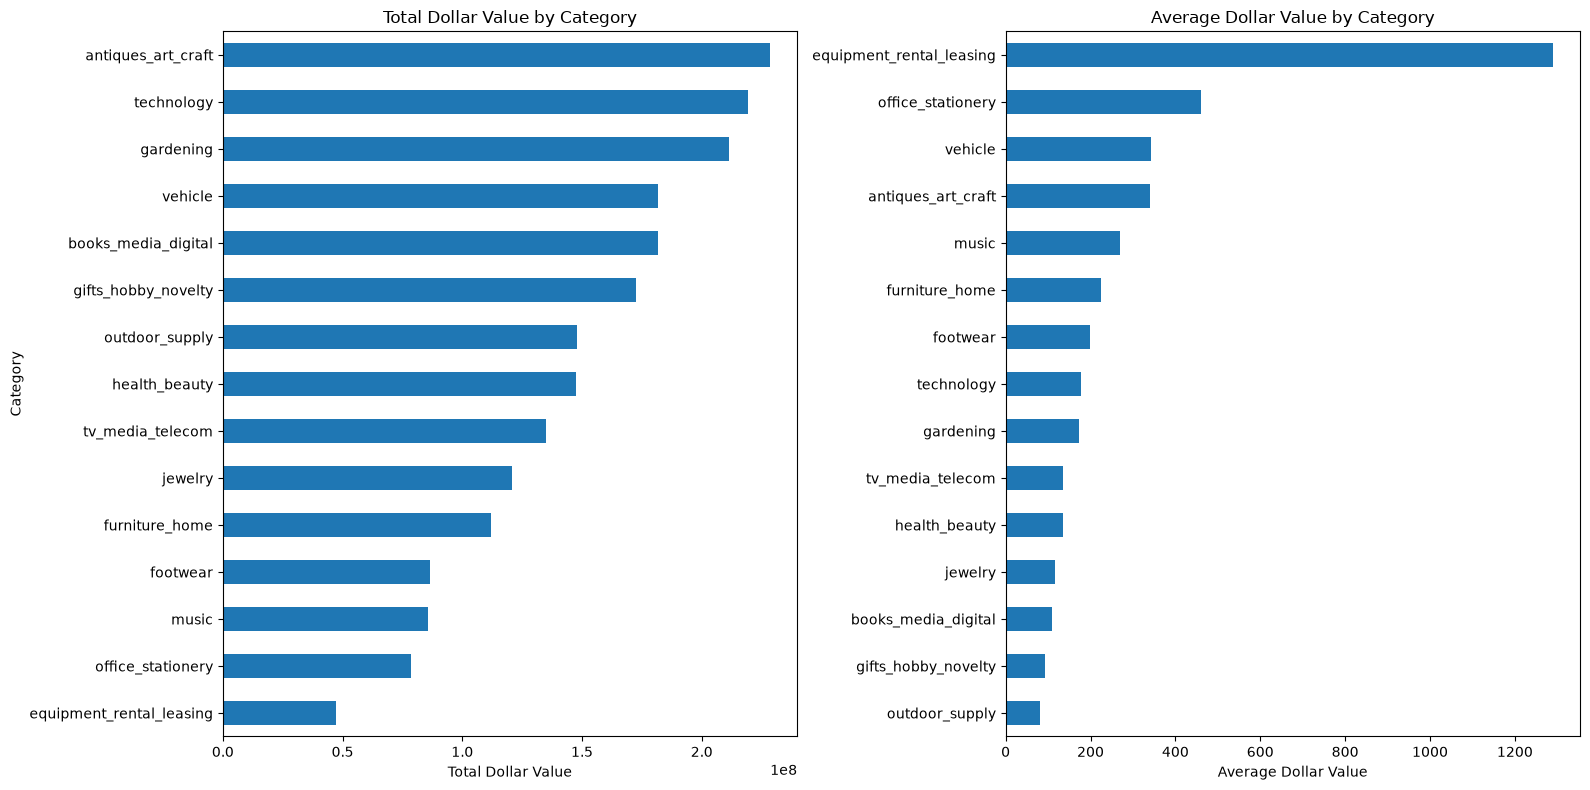

In [152]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

category_pdf = merchant_summary_category.toPandas()

category_pdf.sort_values("total_dollar_value").plot(
    kind="barh",
    x="category_group",
    y="total_dollar_value",
    ax=axes[0],
    legend=False
)

axes[0].set_title("Total Dollar Value by Category")
axes[0].set_xlabel("Total Dollar Value")
axes[0].set_ylabel("Category")

# Average dollar value
category_pdf.sort_values("average_dollar_value").plot(
    kind="barh",
    x="category_group",
    y="average_dollar_value",
    ax=axes[1],
    legend=False
)

axes[1].set_title("Average Dollar Value by Category")
axes[1].set_xlabel("Average Dollar Value")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

# Consumer Demographics

In [124]:
df.groupBy("state", "gender").agg(F.countDistinct("consumer_id").alias("n_consumers")).show()

+-----+-----------+-----------+
|state|     gender|n_consumers|
+-----+-----------+-----------+
|  QLD|       Male|       1607|
|   WA|       Male|       1752|
|  ACT|     Female|        104|
|  TAS|Undisclosed|         95|
|   SA|     Female|       1231|
|  VIC|Undisclosed|        570|
|  QLD|     Female|       1603|
|  NSW|     Female|       3075|
|  NSW|Undisclosed|        687|
|   WA|Undisclosed|        381|
|   NT|Undisclosed|         37|
|   NT|     Female|        154|
|   SA|Undisclosed|        304|
|   NT|       Male|        152|
|   WA|     Female|       1679|
|  VIC|       Male|       2530|
|  ACT|Undisclosed|         21|
|  VIC|     Female|       2466|
|  QLD|Undisclosed|        352|
|  NSW|       Male|       3186|
+-----+-----------+-----------+
only showing top 20 rows


In [125]:
df_counts = (
    df
    .groupBy("state", "gender")
    .agg(F.countDistinct("consumer_id").alias("n_consumers"))
)

pdf = df_counts.toPandas()

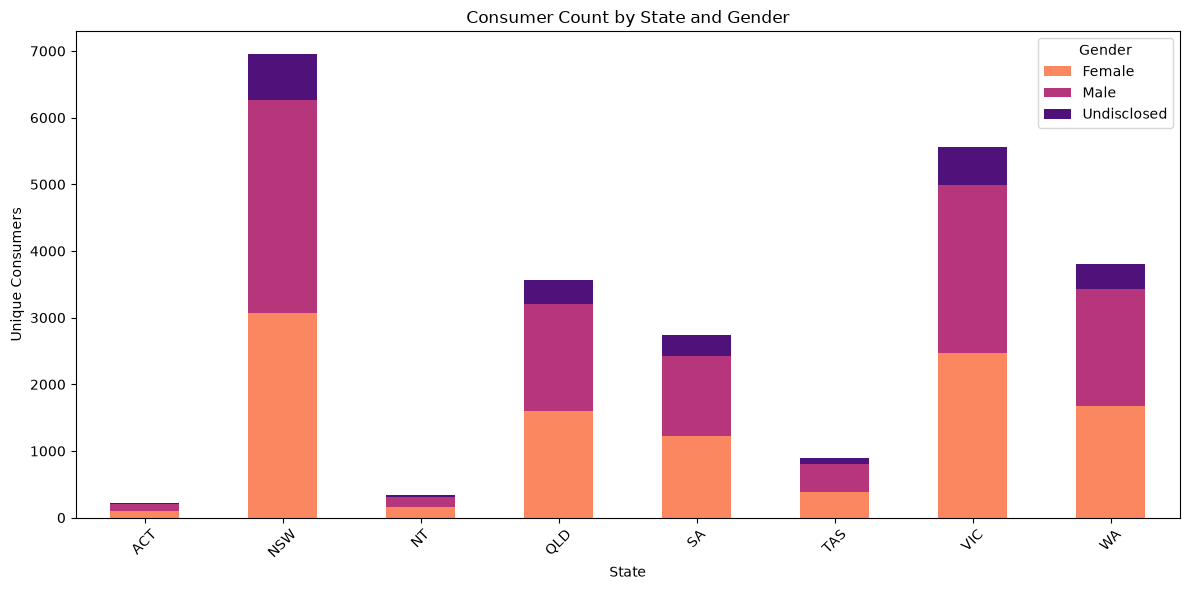

In [126]:
pivot = (
    pdf
    .pivot(index="state", columns="gender", values="n_consumers")
    .fillna(0)
)

pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    color=plt.cm.magma_r([0.25, 0.5, 0.75])
)

plt.title("Consumer Count by State and Gender")
plt.xlabel("State")
plt.ylabel("Unique Consumers")
plt.xticks(rotation=45)
plt.legend(title="Gender")
plt.tight_layout()
plt.show()

# Socioeconomic 

In [127]:
(df
    .filter(F.col("poa_irsad_decile").isNotNull())
    .groupBy("poa_irsad_decile")
    .agg(
        F.avg("dollar_value").alias("avg_spend"),
        F.avg("fraud_probability").alias("avg_fraud_prob"),
        F.avg("Median_tot_hhd_inc_weekly").alias("avg_hhd_income"),
        F.avg("prop_18_34").alias("avg_prop_young"),
    )
    .orderBy("poa_irsad_decile")
    .show())

+----------------+------------------+------------------+------------------+-------------------+
|poa_irsad_decile|         avg_spend|    avg_fraud_prob|    avg_hhd_income|     avg_prop_young|
+----------------+------------------+------------------+------------------+-------------------+
|             1.0|157.23515475022035|14.608459629130264|1230.7237184162216|0.19138165804550036|
|             2.0|159.11463986153768|14.629538031450984| 1249.591519483515|0.16775686509557006|
|             3.0| 158.9398181882747|14.468942103358906|1313.1664784897678| 0.1684997599824199|
|             4.0|  158.301472634759|14.469173350378432|1388.4463183584014|0.17352954741434176|
|             5.0|158.24672361332762|14.620540867154006|1471.0462691587718|0.18040692139734435|
|             6.0| 158.6468966922716|14.812777626743927|1558.1920684938877|0.18614817700421699|
|             7.0|158.77335711431502|14.430550999955571|1631.0353524174689|0.18629975512920596|
|             8.0|158.11007551306156|14.

**RBA Rate**

In [128]:
(df.groupBy("rba_rate_hike_day")
    .agg(F.avg("dollar_value").alias("avg_txn_value"), F.count("*").alias("n_txn"))
    .show())

+-----------------+------------------+--------+
|rba_rate_hike_day|     avg_txn_value|   n_txn|
+-----------------+------------------+--------+
|                1|158.51091319130794|  139931|
|                0|158.43530697296342|13474744|
+-----------------+------------------+--------+



# Fraud

In [129]:
df.stat.corr("fraud_probability", "poa_irsad_score")
df.groupBy("category_group").agg(F.avg("avg_merchant_fraud_prob").alias("avg_fraud")).orderBy(F.desc("avg_fraud")).show()

+--------------------+------------------+
|      category_group|         avg_fraud|
+--------------------+------------------+
| books_media_digital| 62.99278699015306|
|             jewelry| 44.37099314100659|
|      outdoor_supply|34.287450580119796|
|            footwear| 31.68168907360809|
|             vehicle| 31.04741509542452|
| gifts_hobby_novelty|30.795676309308888|
|      furniture_home| 30.75805162717867|
|           gardening|30.016230147935087|
|  antiques_art_craft|29.706793735344338|
|          technology| 29.66437286110531|
|       health_beauty|29.002565290049695|
|   office_stationery| 28.88064813052188|
|    tv_media_telecom|28.695055064880297|
|               music|              NULL|
|equipment_rental_...|              NULL|
+--------------------+------------------+



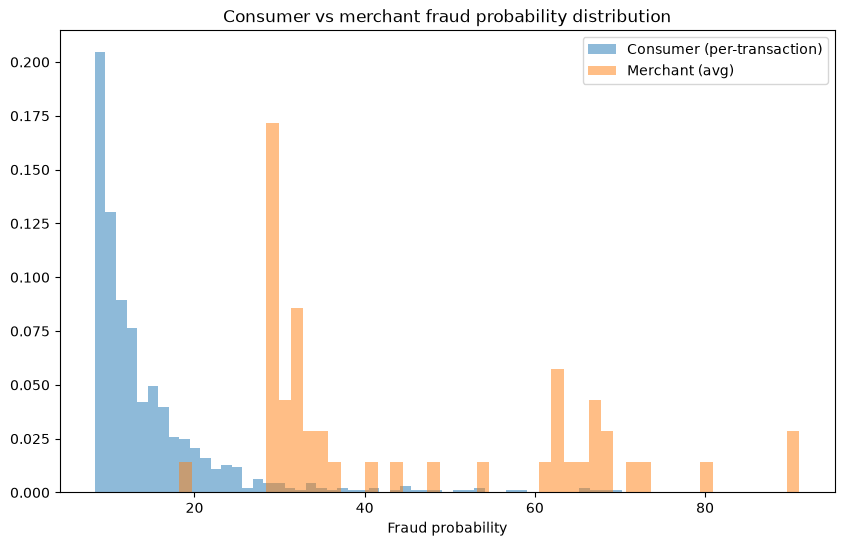

In [130]:
pdf_consumer = df.select("fraud_probability").sample(0.01).toPandas()
pdf_merchant = (
    df.select("merchant_abn", "avg_merchant_fraud_prob")
    .distinct()
    .toPandas()
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(pdf_consumer["fraud_probability"], bins=50, alpha=0.5, label="Consumer (per-transaction)", density=True)
ax.hist(pdf_merchant["avg_merchant_fraud_prob"].dropna(), bins=50, alpha=0.5, label="Merchant (avg)", density=True)
ax.set_xlabel("Fraud probability")
ax.legend()
ax.set_title("Consumer vs merchant fraud probability distribution")
plt.show()

/tmp/ipykernel_4432/3973819333.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0].boxplot(pdf_consumer["fraud_probability"].dropna(), vert=True)
/tmp/ipykernel_4432/3973819333.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(pdf_merchant["avg_merchant_fraud_prob"].dropna(), vert=True)


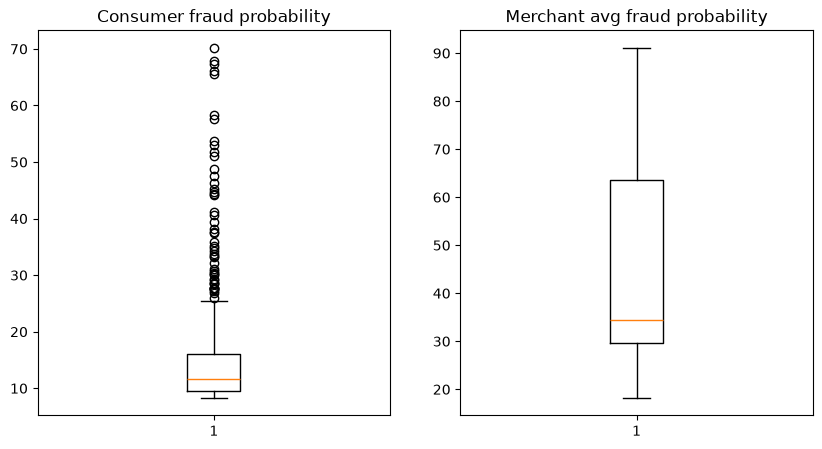

In [131]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].boxplot(pdf_consumer["fraud_probability"].dropna(), vert=True)
axes[0].set_title("Consumer fraud probability")
axes[1].boxplot(pdf_merchant["avg_merchant_fraud_prob"].dropna(), vert=True)
axes[1].set_title("Merchant avg fraud probability")
plt.show()

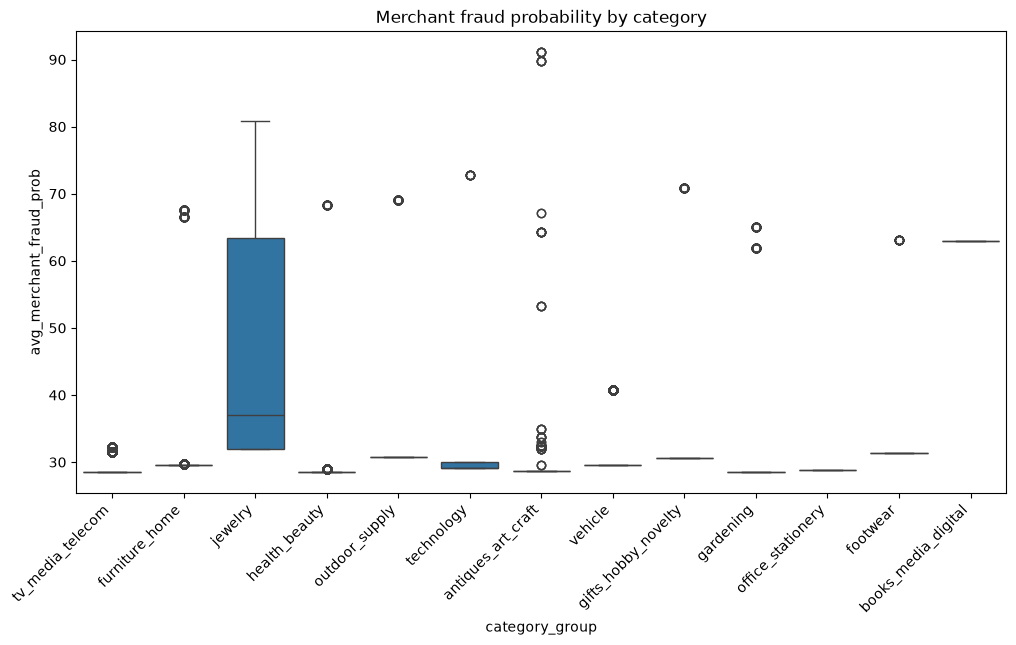

In [132]:
pdf_cat = (
    df.select("category_group", "avg_merchant_fraud_prob")
    .dropna()
    .sample(0.05)
    .toPandas()
)

plt.figure(figsize=(12, 6))
sns.boxplot(data=pdf_cat, x="category_group", y="avg_merchant_fraud_prob")
plt.xticks(rotation=45, ha="right")
plt.title("Merchant fraud probability by category")
plt.show()

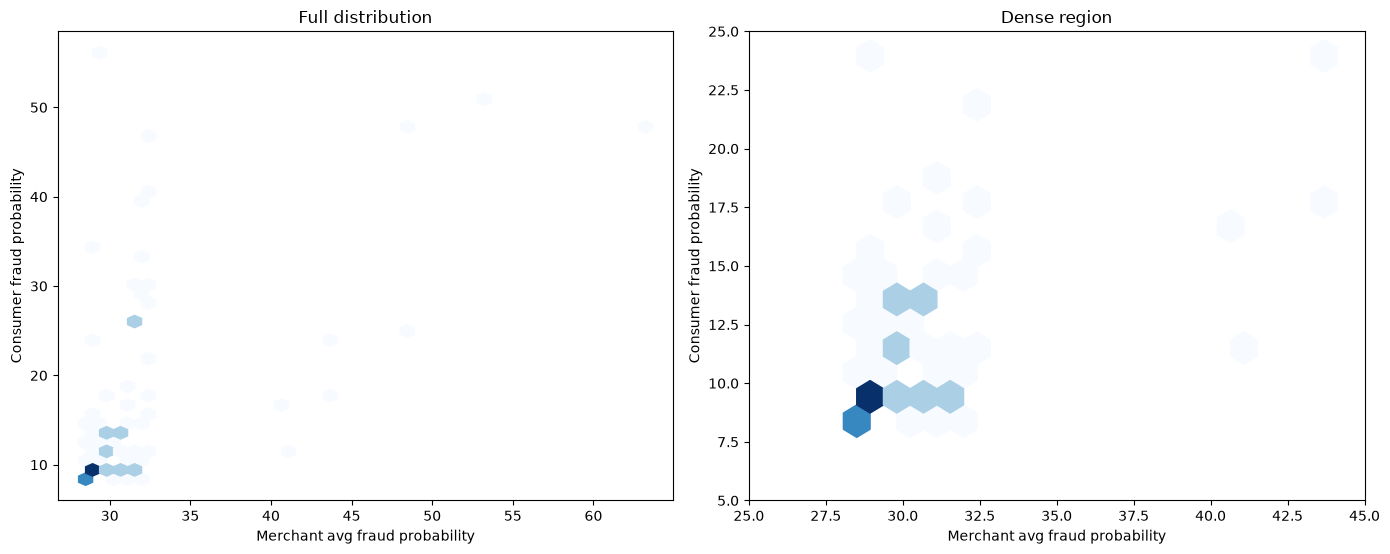

In [133]:
pdf_both = (
    df.select("fraud_probability", "avg_merchant_fraud_prob")
    .dropna()
    .sample(0.01)
    .toPandas()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Full range
axes[0].hexbin(
    pdf_both["avg_merchant_fraud_prob"],
    pdf_both["fraud_probability"],
    gridsize=40,
    cmap="Blues",
    mincnt=1
)
axes[0].set_title("Full distribution")
axes[0].set_xlabel("Merchant avg fraud probability")
axes[0].set_ylabel("Consumer fraud probability")

# Zoom into dense region
axes[1].hexbin(
    pdf_both["avg_merchant_fraud_prob"],
    pdf_both["fraud_probability"],
    gridsize=40,
    cmap="Blues",
    mincnt=1
)
axes[1].set_xlim(25, 45)
axes[1].set_ylim(5, 25)
axes[1].set_title("Dense region")
axes[1].set_xlabel("Merchant avg fraud probability")
axes[1].set_ylabel("Consumer fraud probability")

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

# Geospatial Analysis

To see if there are any relationships between location (eg: state vs. state, city vs suburban) and BNPL spending habits. 

In [134]:
# formatting for geospatial plots

states_url = (
    "https://naturalearth.s3.amazonaws.com/"
    "10m_cultural/ne_10m_admin_1_states_provinces.zip"
)

states = gpd.read_file(states_url)

states = states[
    states["admin"].str.contains("Australia", case=False, na=False)
].copy()

cities = {
    "Darwin": (130.8456, -12.4634),
    "Perth": (115.8605, -31.9505),
    "Adelaide": (138.6007, -34.9285),
    "Brisbane": (153.0251, -27.4698),
    "Sydney": (151.2093, -33.8688),
    "Canberra": (149.1300, -35.2809),
    "Melbourne": (144.9631, -37.8136),
    "Hobart": (147.3272, -42.8821),
}

city_gdf = gpd.GeoDataFrame(
    [
        {
            "city": city,
            "geometry": Point(lon, lat)
        }
        for city, (lon, lat) in cities.items()
    ],
    crs="EPSG:4326"
)

def plot_australia(
    gdf,
    column,
    title,
    cmap="magma",
    figsize=(14, 8),
    legend=True,
    state_borders=True,
    show_cities=True,
    missing_color="lightgrey",
    border_color="white",
    border_width=1.0,
    vmin=None,
    vmax=None
):
    """
    Standardised Australia choropleth map.

    Parameters
    ----------
    gdf : GeoDataFrame
        Geographic data to plot.

    column : str
        Column used to colour the map.

    title : str
        Map title.

    cmap : str
        Matplotlib colourmap.

    figsize : tuple
        Figure dimensions.

    legend : bool
        Whether to show the colour legend.

    state_borders : bool
        Whether to show state/territory borders.

    show_cities : bool
        Whether to show major city locations.
    """

    gdf_plot = gdf.to_crs("EPSG:3577")

    states_plot = states.to_crs("EPSG:3577")
    cities_plot = city_gdf.to_crs("EPSG:3577")

    fig, ax = plt.subplots(
        figsize=figsize,
        facecolor="white"
    )

    gdf_plot.plot(
        column=column,
        cmap=cmap,
        legend=legend,
        ax=ax,
        linewidth=0,
        vmin=vmin,
        vmax=vmax,
        missing_kwds={
            "color": missing_color,
            "edgecolor": "white"
        },
        zorder=2
    )

    if state_borders:
        states_plot.boundary.plot(
            ax=ax,
            color=border_color,
            linewidth=border_width,
            alpha=0.9,
            zorder=1
        )

    if show_cities:

        cities_plot.plot(
            ax=ax,
            color="red",
            edgecolor="black",
            linewidth=0.8,
            markersize=35,
            zorder=1
        )

        offsets = {
            "Darwin": (6, 6),
            "Perth": (6, 6),
            "Adelaide": (6, -14),
            "Melbourne": (6, -14),
            "Hobart": (6, -14),
            "Canberra": (6, 6),
            "Sydney": (6, 6),
            "Brisbane": (6, 6),
        }

        for _, row in cities_plot.iterrows():

            ax.annotate(
                row["city"],
                xy=(
                    row.geometry.x,
                    row.geometry.y
                ),
                xytext=offsets.get(
                    row["city"],
                    (6, 6)
                ),
                textcoords="offset points",
                fontsize=9,
                color="white",
                weight="bold",
                zorder=6,
                path_effects=[
                    pe.withStroke(
                        linewidth=2.5,
                        foreground="black"
                    )
                ]
            )

    xmin, ymin, xmax, ymax = gdf_plot.total_bounds

    xpad = (xmax - xmin) * 0.02
    ypad = (ymax - ymin) * 0.02

    ax.set_xlim(
        xmin - xpad,
        xmax + xpad
    )

    ax.set_ylim(
        ymin - ypad,
        ymax + ypad
    )

    ax.set_title(
        title,
        fontsize=16,
        fontweight="bold",
        pad=12
    )

    ax.set_axis_off()

    plt.tight_layout()

    return fig, ax

Spend (per capita) grouped by postcode

In [135]:
postcode_stats = (
    df
    .groupBy("postcode")
    .agg(
        F.sum("dollar_value").alias("total_spend"),
        F.count("*").alias("n_txn"),
        F.avg("fraud_probability").alias("avg_fraud_prob"),
        F.avg("poa_population").alias("population"),
    )
    .toPandas()
)

postcode_stats["spend_per_capita"] = postcode_stats["total_spend"] / postcode_stats["population"]

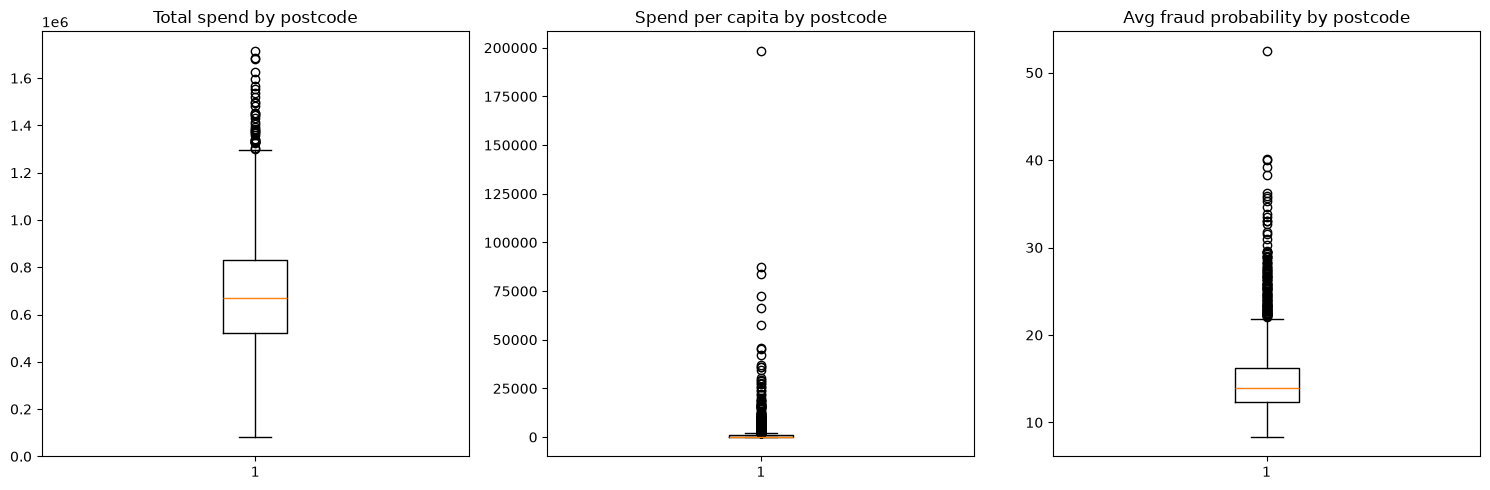

In [136]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].boxplot(postcode_stats["total_spend"].dropna())
axes[0].set_title("Total spend by postcode")

axes[1].boxplot(postcode_stats["spend_per_capita"].dropna())
axes[1].set_title("Spend per capita by postcode")

axes[2].boxplot(postcode_stats["avg_fraud_prob"].dropna())
axes[2].set_title("Avg fraud probability by postcode")

plt.tight_layout()
plt.show()

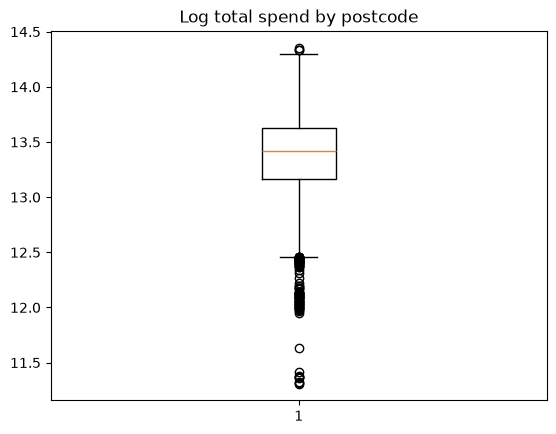

In [137]:
# transform data to fix skewness
postcode_stats["log_total_spend"] = np.log1p(postcode_stats["total_spend"])

plt.boxplot(postcode_stats["log_total_spend"].dropna())
plt.title("Log total spend by postcode")
plt.show()

In [138]:
# filter out small population
postcode_stats.sort_values("spend_per_capita", ascending=False).head(10)[["postcode", "population", "total_spend", "spend_per_capita"]]

# a) filter out unreliable small-population postcodes before computing per-capita
postcode_stats_filtered = postcode_stats[postcode_stats["population"] >= 100].copy()

# b) then log-transform what's left
postcode_stats_filtered["log_spend_per_capita"] = np.log1p(postcode_stats_filtered["spend_per_capita"])

In [139]:
poa = gpd.read_file("../data/landing/POA_2021_AUST_GDA2020.shp")[["POA_CODE21", "geometry"]]
poa = poa.rename(columns={"POA_CODE21": "postcode"})

poa_geo = poa.merge(postcode_stats, on="postcode", how="left")

In [140]:
# for spend-per-capita and orders-per-capita maps
poa_geo_filtered = poa.merge(postcode_stats_filtered, on="postcode", how="left")

# for total spend and fraud maps (no population filter needed)
poa_geo = poa.merge(postcode_stats, on="postcode", how="left")

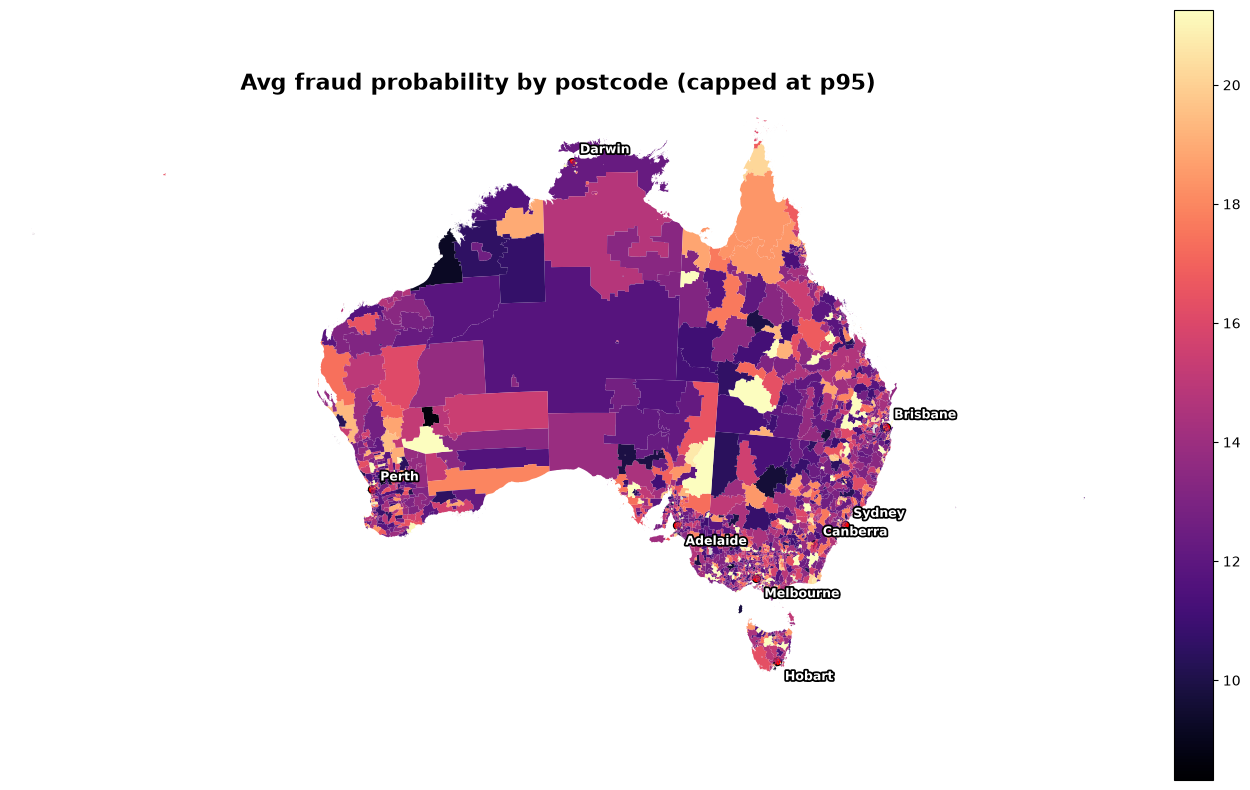

In [141]:
vmax = poa_geo["avg_fraud_prob"].quantile(0.95)

fig, ax = plot_australia(
    poa_geo,
    column="avg_fraud_prob",
    title="Avg fraud probability by postcode (capped at p95)",
    cmap="magma",
    legend=True,
    vmax=vmax
)

plt.show()

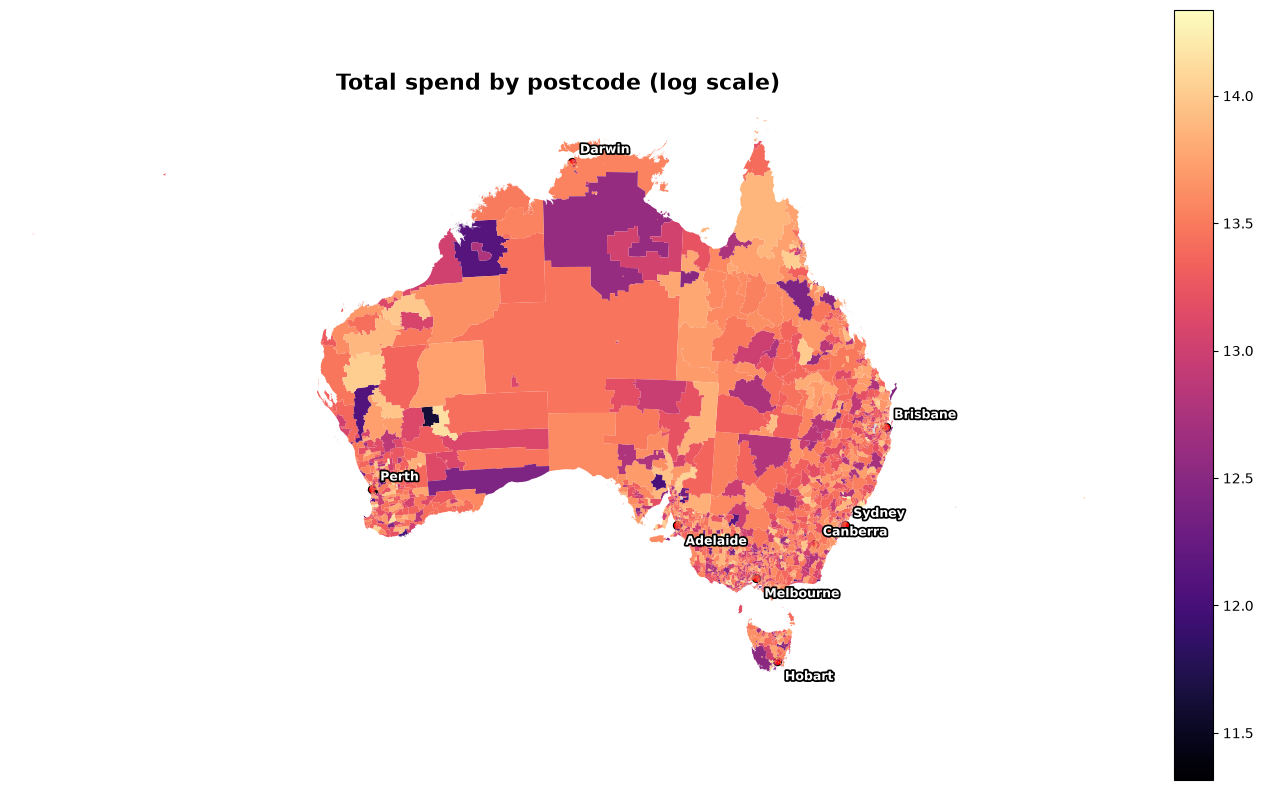

In [142]:
fig, ax = plot_australia(
    poa_geo,
    column="log_total_spend",
    title="Total spend by postcode (log scale)",
    cmap="magma",
    legend=True
)

plt.show()

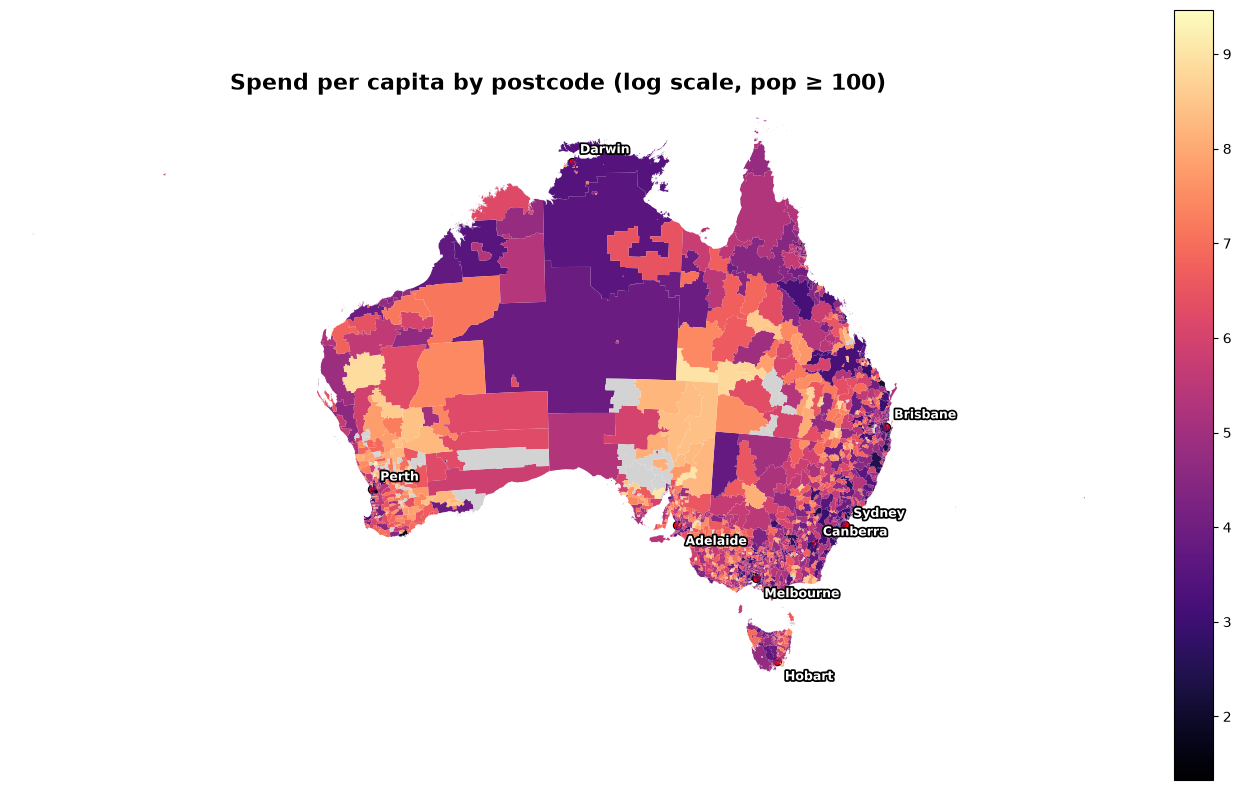

In [143]:
fig, ax = plot_australia(
    poa_geo_filtered,
    column="log_spend_per_capita",
    title="Spend per capita by postcode (log scale, pop ≥ 100)",
    cmap="magma",
    legend=True
)

plt.show()

Orders (per capita) grouuped by postcode

In [144]:
postcode_stats["orders_per_capita"] = postcode_stats["n_txn"] / postcode_stats["population"]
postcode_stats["log_n_txn"] = np.log1p(postcode_stats["n_txn"])

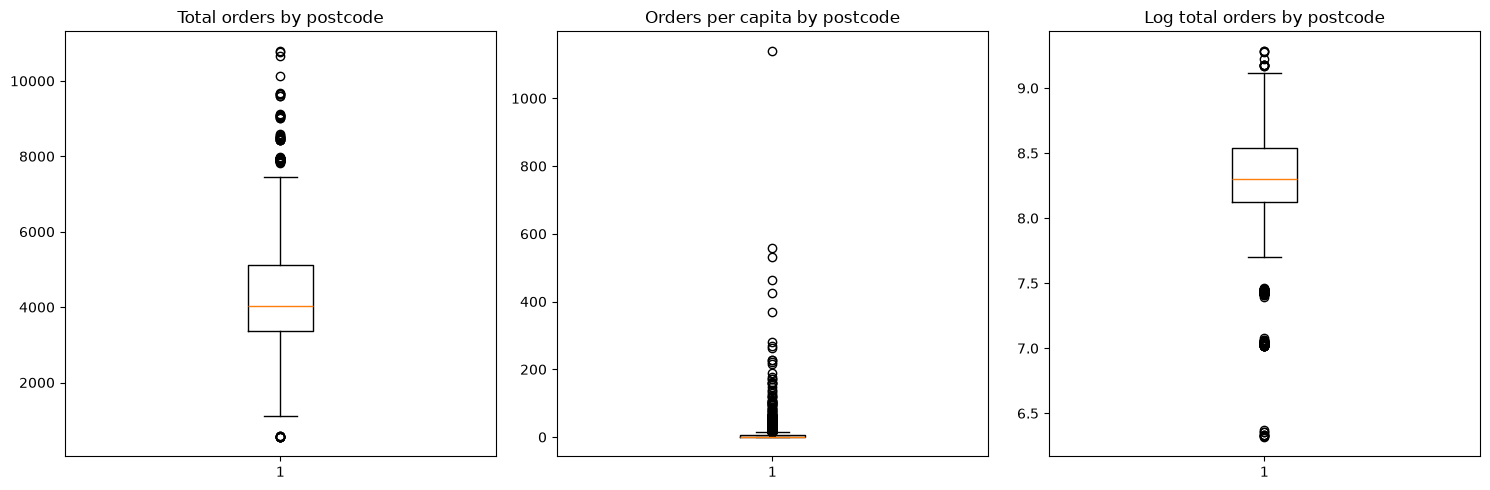

In [145]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].boxplot(postcode_stats["n_txn"].dropna())
axes[0].set_title("Total orders by postcode")

axes[1].boxplot(postcode_stats["orders_per_capita"].dropna())
axes[1].set_title("Orders per capita by postcode")

axes[2].boxplot(postcode_stats["log_n_txn"].dropna())
axes[2].set_title("Log total orders by postcode")

plt.tight_layout()
plt.show()

In [146]:
postcode_stats.sort_values("orders_per_capita", ascending=False).head(10)[
    ["postcode", "population", "n_txn", "orders_per_capita"]
]

,postcode,population,n_txn,orders_per_capita
2384,6452,4.0,4563,1140.750000
2186,4479,7.0,3897,556.714286
2921,6470,20.0,10660,533.000000
1780,4009,11.0,5099,463.545455
2178,6385,20.0,8501,425.050000
2430,5713,20.0,7374,368.700000
2491,3415,36.0,10139,281.638889
736,4493,19.0,5094,268.105263
1442,6467,30.0,7927,264.233333
1771,3893,25.0,5717,228.680000


In [147]:
# reuse the population filter already applied for spend-per-capita
postcode_stats_filtered["orders_per_capita"] = (
    postcode_stats_filtered["n_txn"] / postcode_stats_filtered["population"]
)
postcode_stats_filtered["log_orders_per_capita"] = np.log1p(
    postcode_stats_filtered["orders_per_capita"]
)

In [148]:
poa_geo = poa.merge(postcode_stats, on="postcode", how="left")
poa_geo_filtered = poa.merge(postcode_stats_filtered, on="postcode", how="left")

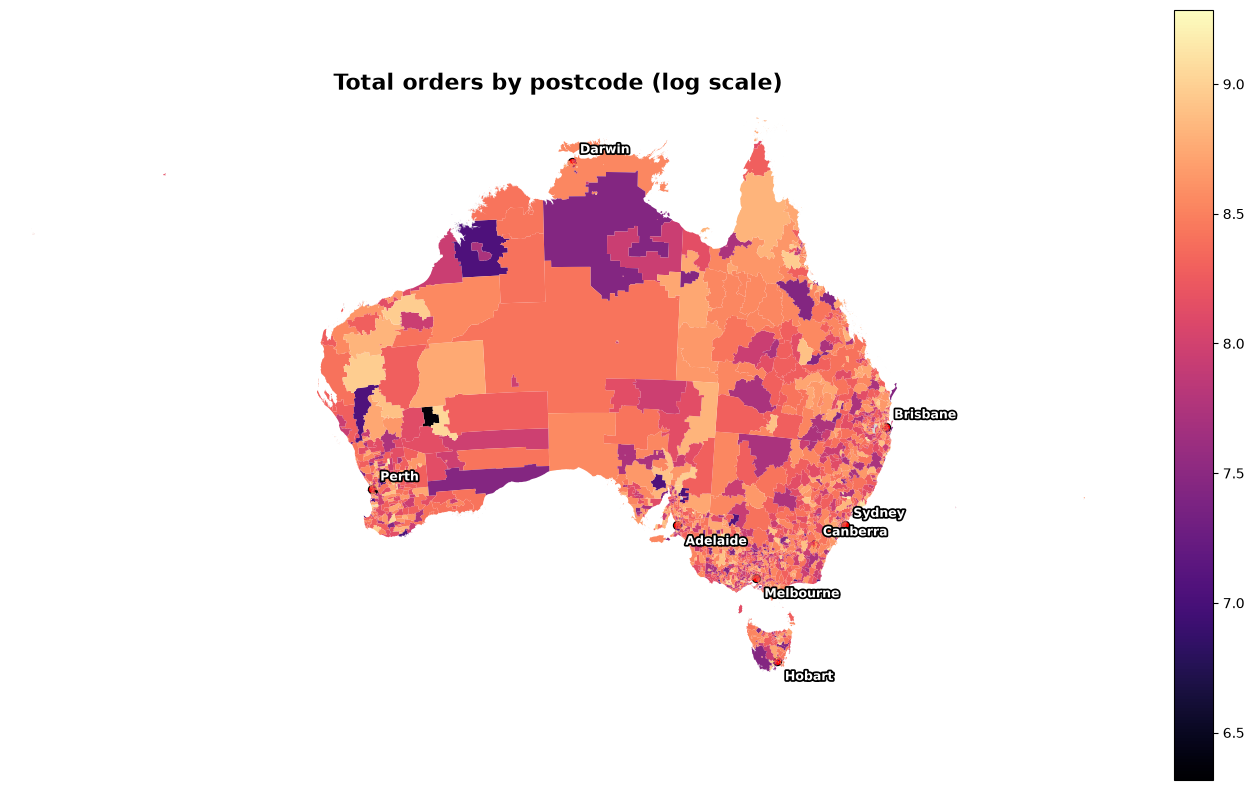

Text(1250.2777777777776, 0.5, 'log(total orders + 1)')

In [149]:
fig, ax = plot_australia(
    poa_geo,
    column="log_n_txn",
    title="Total orders by postcode (log scale)",
    cmap="magma",
    legend=True
)

plt.show()

cbar = ax.get_figure().axes[-1]
cbar.set_ylabel("log(total orders + 1)")

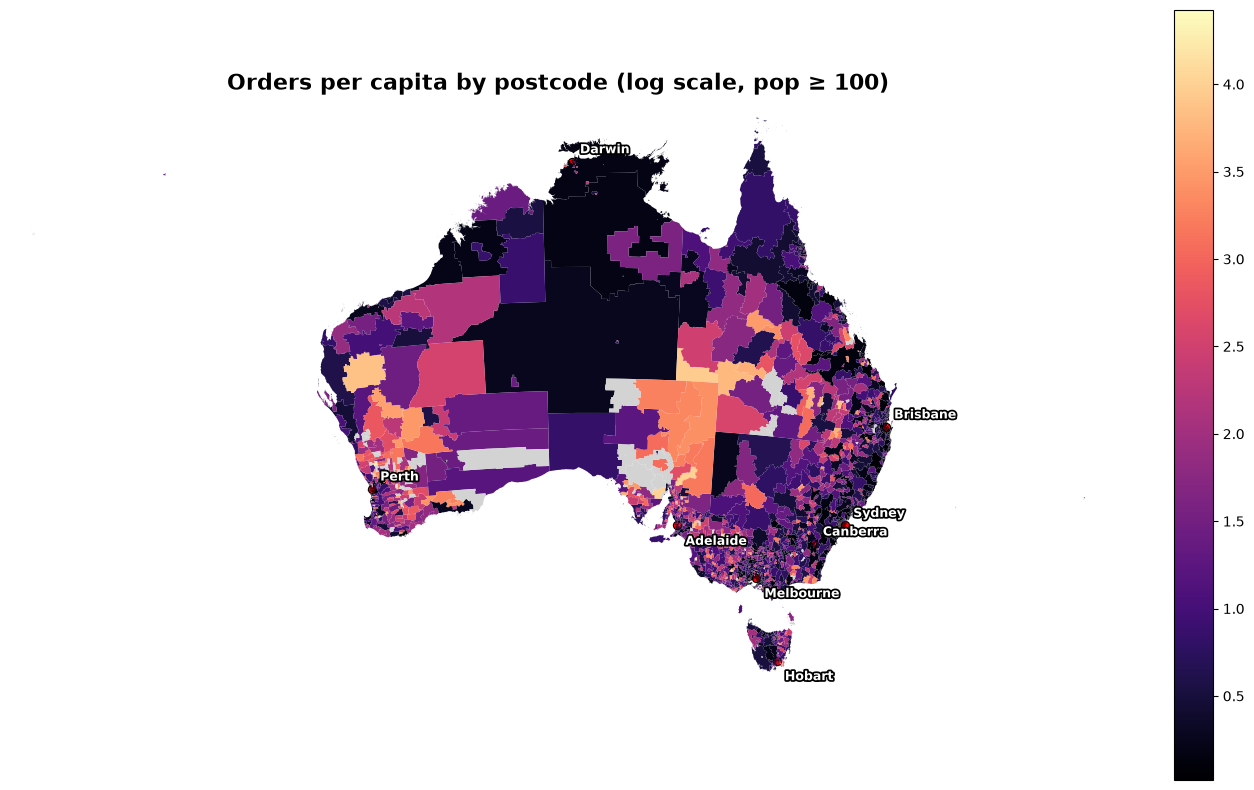

Text(1250.2777777777776, 0.5, 'log(orders per capita + 1)')

In [150]:
fig, ax = plot_australia(
    poa_geo_filtered,
    column="log_orders_per_capita",
    title="Orders per capita by postcode (log scale, pop ≥ 100)",
    cmap="magma",
    legend=True
)

plt.show()

cbar = ax.get_figure().axes[-1]
cbar.set_ylabel("log(orders per capita + 1)")